In [38]:
import sys
sys.executable

'/Users/paigeblackstone/projects/f1-worldchamp/.venv/bin/python'

In [39]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/Users/paigeblackstone/Library/Mobile Documents/com~apple~CloudDocs/Formula 1 Fun")
csv_files = sorted(DATA_DIR.glob("*.csv"))
len(csv_files), [p.name for p in csv_files[:10]]


(14,
 ['circuits.csv',
  'constructor_results.csv',
  'constructor_standings.csv',
  'constructors.csv',
  'driver_standings.csv',
  'drivers.csv',
  'lap_times.csv',
  'pit_stops.csv',
  'qualifying.csv',
  'races.csv'])

In [40]:
tables = {p.stem.lower(): pd.read_csv(p) for p in csv_files}
sorted(tables.keys())

['circuits',
 'constructor_results',
 'constructor_standings',
 'constructors',
 'driver_standings',
 'drivers',
 'lap_times',
 'pit_stops',
 'qualifying',
 'races',
 'results',
 'seasons',
 'sprint_results',
 'status']

In [42]:
summary = (
    pd.DataFrame([{"table": k, "rows": v.shape[0], "cols": v.shape[1]} for k, v in tables.items()])
      .sort_values("rows", ascending=False)
      .reset_index(drop=True)
)
summary.head(15)

,table,rows,cols
0,lap_times,589081,6
1,driver_standings,34863,7
2,results,26759,18
3,constructor_standings,13391,7
4,constructor_results,12625,5
5,pit_stops,11371,7
6,qualifying,10494,9
7,races,1125,18
8,drivers,861,9
9,sprint_results,360,16


In [43]:
for name in ["results", "races", "drivers", "constructors", "circuits", "qualifying"]:
    print("\n", name.upper())
    print(tables[name].columns.tolist())


 RESULTS
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

 RACES
['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']

 DRIVERS
['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']

 CONSTRUCTORS
['constructorId', 'constructorRef', 'name', 'nationality', 'url']

 CIRCUITS
['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']

 QUALIFYING
['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']


In [44]:
assert tables["races"]["raceId"].is_unique
assert tables["drivers"]["driverId"].is_unique
assert tables["constructors"]["constructorId"].is_unique
assert tables["results"]["resultId"].is_unique

In [45]:
tables["results"].groupby(["raceId", "driverId"]).size().value_counts()

1    26583
2       79
3        6
Name: count, dtype: int64

In [46]:
set(tables["results"]["raceId"]) - set(tables["races"]["raceId"])
set(tables["results"]["raceId"]) - set(tables["drivers"]["driverId"])
set(tables["results"]["raceId"]) - set(tables["constructors"]["constructorId"])

{43,
 165,
 212,
 216,
 217,
 218,
 219,
 220,
 221,
 222,
 223,
 224,
 225,
 226,
 227,
 228,
 229,
 230,
 231,
 232,
 233,
 234,
 235,
 236,
 237,
 238,
 239,
 240,
 241,
 242,
 243,
 244,
 245,
 246,
 247,
 248,
 249,
 250,
 251,
 252,
 253,
 254,
 255,
 256,
 257,
 258,
 259,
 260,
 261,
 262,
 263,
 264,
 265,
 266,
 267,
 268,
 269,
 270,
 271,
 272,
 273,
 274,
 275,
 276,
 277,
 278,
 279,
 280,
 281,
 282,
 283,
 284,
 285,
 286,
 287,
 288,
 289,
 290,
 291,
 292,
 293,
 294,
 295,
 296,
 297,
 298,
 299,
 300,
 301,
 302,
 303,
 304,
 305,
 306,
 307,
 308,
 309,
 310,
 311,
 312,
 313,
 314,
 315,
 316,
 317,
 318,
 319,
 320,
 321,
 322,
 323,
 324,
 325,
 326,
 327,
 328,
 329,
 330,
 331,
 332,
 333,
 334,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 342,
 343,
 344,
 345,
 346,
 347,
 348,
 349,
 350,
 351,
 352,
 353,
 354,
 355,
 356,
 357,
 358,
 359,
 360,
 361,
 362,
 363,
 364,
 365,
 366,
 367,
 368,
 369,
 370,
 371,
 372,
 373,
 374,
 375,
 376,
 377,
 378,
 379,

In [47]:
results = tables["results"].copy()


In [48]:
results["target_points"] = (results["points"] > 0).astype(int)
results[["points", "target_points"]].head()


,points,target_points
0,10.0,1
1,8.0,1
2,6.0,1
3,5.0,1
4,4.0,1


In [49]:
results = tables["results"].copy()
results["target_points"] = (results["points"] > 0).astype(int)
results["target_points"].value_counts()


target_points
0    18589
1     8170
Name: count, dtype: int64

In [50]:
import pandas as pd

# --- Load fresh copies ---
results = tables["results"].copy()
races = tables["races"].copy()
drivers = tables["drivers"].copy()
constructors = tables["constructors"].copy()
circuits = tables["circuits"].copy()
status = tables["status"].copy()

# --- Parse date ---
races["date"] = pd.to_datetime(races["date"], errors="coerce")

# --- Drop url columns before merging ---
for df in [races, drivers, constructors, circuits]:
    if "url" in df.columns:
        df.drop(columns="url", inplace=True)

# --- Build master table ---
master = (
    results
    .merge(races, on="raceId", how="left", validate="m:1")
    .merge(drivers, on="driverId", how="left", validate="m:1")
    .merge(constructors, on="constructorId", how="left", validate="m:1")
    .merge(circuits, on="circuitId", how="left", validate="m:1")
    .merge(status, on="statusId", how="left", validate="m:1")
)

master.shape

(26759, 52)

In [31]:
# import pandas as pd

# # --- Load fresh copies ---
# results = tables["results"].copy()
# races = tables["races"].copy()
# drivers = tables["drivers"].copy()
# constructors = tables["constructors"].copy()
# circuits = tables["circuits"].copy()
# status = tables["status"].copy()

# # --- Parse date ---
# races["date"] = pd.to_datetime(races["date"], errors="coerce")

# # --- Drop url columns before merging ---
# for df in [races, drivers, constructors, circuits]:
#     if "url" in df.columns:
#         df.drop(columns="url", inplace=True)

# # --- Build master table ---
# master = (
#     results
#     .merge(races, on="raceId", how="left", validate="m:1")
#     .merge(drivers, on="driverId", how="left", validate="m:1")
#     .merge(constructors, on="constructorId", how="left", validate="m:1")
#     .merge(circuits, on="circuitId", how="left", validate="m:1")
#     .merge(status, on="statusId", how="left", validate="m:1")
# )

# master.shape

In [51]:
master["target_points"] = (master["points"] > 0).astype(int)
master[["points", "target_points"]].head()

,points,target_points
0,10.0,1
1,8.0,1
2,6.0,1
3,5.0,1
4,4.0,1


In [52]:
qualifying = tables["qualifying"].copy()

master = (
    master
    .merge(
        qualifying[["raceId", "driverId", "position"]],
        on=["raceId", "driverId"],
        how="left",
        validate="m:1"
    )
    .rename(columns={"position": "qualifying_position"})
)

master.shape

(26759, 54)

In [53]:
[c for c in master.columns if "position" in c.lower()]

['position_x', 'positionText', 'positionOrder', 'position_y']

In [54]:
master.columns.tolist()[-10:]

['circuitRef',
 'name',
 'location',
 'country',
 'lat',
 'lng',
 'alt',
 'status',
 'target_points',
 'position_y']

In [55]:
master.groupby("grid")["target_points"].mean().head(10)

grid
0    0.008547
1    0.728873
2    0.683556
3    0.671681
4    0.627208
5    0.575088
6    0.535111
7    0.498678
8    0.436670
9    0.423145
Name: target_points, dtype: float64

In [56]:
master.groupby("qualifying_position")["target_points"].mean().head(10)

KeyError: 'qualifying_position'

In [58]:
master = master.drop(
    columns=[c for c in master.columns if c in ["qualifying_position", "position_x", "position_y"]],
    errors="ignore"
)

In [59]:
qualifying = tables["qualifying"].copy()

qualifying = qualifying.rename(columns={"position": "qualifying_position"})

master = (
    master
    .merge(
        qualifying[["raceId", "driverId", "qualifying_position"]],
        on=["raceId", "driverId"],
        how="left",
        validate="m:1"
    )
)

master.shape

(26759, 53)

In [60]:
[c for c in master.columns if "position" in c.lower()]

['positionText', 'positionOrder', 'qualifying_position']

In [61]:
master["grid"].value_counts().sort_index().head(15)

grid
0     1638
1     1136
2     1125
3     1130
4     1132
5     1132
6     1125
7     1135
8     1129
9     1132
10    1130
11    1132
12    1127
13    1125
14    1120
Name: count, dtype: int64

In [62]:
master.loc[master["grid"] == 0, ["year", "name_x", "driverId", "constructorId", "positionOrder", "points"]].head(20)

,year,name_x,driverId,constructorId,positionOrder,points
2281,2002,San Marino Grand Prix,62,18,22,0.0
2432,2002,French Grand Prix,49,21,20,0.0
2433,2002,French Grand Prix,59,21,21,0.0
2434,2002,French Grand Prix,21,17,22,0.0
2797,2001,British Grand Prix,58,18,22,0.0
2972,2000,Brazilian Grand Prix,64,15,21,0.0
2973,2000,Brazilian Grand Prix,63,15,22,0.0
3346,1999,Brazilian Grand Prix,41,16,22,0.0
3785,1998,Monaco Grand Prix,73,25,22,0.0
4003,1998,Japanese Grand Prix,73,25,22,0.0


In [63]:
[c for c in master.columns if "name" in c.lower()]

['name_x', 'forename', 'surname', 'name_y', 'name']

In [64]:
model_a = master[[
    "target_points", "grid", "year", "driverId", "constructorId", "circuitId"
]].copy()

model_b = master[[
    "target_points", "grid", "qualifying_position", "year", "driverId", "constructorId", "circuitId"
]].dropna().copy()

model_a.shape, model_b.shape

((26759, 6), (10494, 7))

In [65]:
model_b["year"].describe()

count    10494.000000
mean      2011.260911
std          8.588508
min       1994.000000
25%       2006.000000
50%       2012.000000
75%       2018.000000
max       2024.000000
Name: year, dtype: float64

In [66]:
model_b["year"].value_counts().sort_index().tail(20)

year
2005    376
2006    396
2007    374
2008    368
2009    340
2010    456
2011    452
2012    476
2013    418
2014    405
2015    374
2016    457
2017    398
2018    420
2019    418
2020    340
2021    439
2022    440
2023    440
2024    479
Name: count, dtype: int64

In [67]:
master["grid"].value_counts().sort_index().head(15)

grid
0     1638
1     1136
2     1125
3     1130
4     1132
5     1132
6     1125
7     1135
8     1129
9     1132
10    1130
11    1132
12    1127
13    1125
14    1120
Name: count, dtype: int64

In [68]:
model_a = master[[
    "target_points", "grid", "year", "driverId", "constructorId", "circuitId"
]].copy()

model_b = master[[
    "target_points", "grid", "qualifying_position", "year", "driverId", "constructorId", "circuitId"
]].dropna().copy()

model_a.shape, model_b.shape

((26759, 6), (10494, 7))

In [69]:
model_b["year"].value_counts().sort_index().tail(20)

year
2005    376
2006    396
2007    374
2008    368
2009    340
2010    456
2011    452
2012    476
2013    418
2014    405
2015    374
2016    457
2017    398
2018    420
2019    418
2020    340
2021    439
2022    440
2023    440
2024    479
Name: count, dtype: int64

In [70]:
master["grid_clean"] = master["grid"].replace(0, pd.NA)

In [71]:
master["grid_clean"].isna().mean()

np.float64(0.06121304981501551)

In [72]:
master["qualifying_position"] = pd.to_numeric(master["qualifying_position"], errors="coerce")

In [73]:
model = master[
    ["target_points", "grid_clean", "qualifying_position", "year", "driverId", "constructorId", "circuitId"]
].dropna().copy()

model.shape

(10407, 7)

In [74]:
train = model[(model["year"] >= 2014) & (model["year"] <= 2021)]
test  = model[model["year"] >= 2022]

In [75]:
train["year"].min(), train["year"].max()
test["year"].min(), test["year"].max()

(np.int64(2022), np.int64(2024))

In [76]:
train["year"].min(), train["year"].max()

(np.int64(2014), np.int64(2021))

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train = train[["grid_clean", "qualifying_position"]]
y_train = train["target_points"]

X_test = test[["grid_clean", "qualifying_position"]]
y_test = test["target_points"]

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

preds = model_lr.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, preds)
roc_auc

0.8463494582844526

In [79]:
master = master.sort_values(["driverId", "date"])

In [80]:
master["driver_avg_finish_last5"] = (
    master
    .groupby("driverId")["positionOrder"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [81]:
master["driver_points_last5"] = (
    master
    .groupby("driverId")["points"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [82]:
master = master.sort_values(["constructorId", "date"])

master["constructor_points_last5"] = (
    master
    .groupby("constructorId")["points"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [83]:
model_v2 = master[
    [
        "target_points",
        "grid_clean",
        "qualifying_position",
        "driver_avg_finish_last5",
        "driver_points_last5",
        "constructor_points_last5",
        "year"
    ]
].dropna().copy()

In [85]:
train = model_v2[(model_v2["year"] >= 2014) & (model_v2["year"] <= 2021)]
test  = model_v2[model_v2["year"] >= 2022]

In [86]:
X_train = train.drop(columns=["target_points"])
y_train = train["target_points"]

X_test = test.drop(columns=["target_points"])
y_test = test["target_points"]

In [87]:
model_v2.shape

(9729, 7)

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train = train.drop(columns=["target_points"])
y_train = train["target_points"]

X_test = test.drop(columns=["target_points"])
y_test = test["target_points"]

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

preds = model_lr.predict_proba(X_test)[:, 1]

roc_auc_v2 = roc_auc_score(y_test, preds)
roc_auc_v2

0.865965965965966

In [89]:
X_train.corr()

,grid_clean,qualifying_position,driver_avg_finish_last5,driver_points_last5,constructor_points_last5,year
grid_clean,1.000000,0.961208,0.690275,-0.672017,-0.673955,-0.044491
qualifying_position,0.961208,1.000000,0.718482,-0.698794,-0.703454,-0.040332
driver_avg_finish_last5,0.690275,0.718482,1.000000,-0.908363,-0.804676,-0.049579
driver_points_last5,-0.672017,-0.698794,-0.908363,1.000000,0.870696,0.011374
constructor_points_last5,-0.673955,-0.703454,-0.804676,0.870696,1.000000,0.006768
year,-0.044491,-0.040332,-0.049579,0.011374,0.006768,1.000000


In [90]:
import pandas as pd

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model_lr.coef_[0]
}).sort_values("coef", ascending=False)

coef_df

,feature,coef
4,constructor_points_last5,0.040694
5,year,0.001953
3,driver_points_last5,-0.056845
0,grid_clean,-0.066475
1,qualifying_position,-0.125659
2,driver_avg_finish_last5,-0.169791


In [91]:
feature_cols = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "constructor_points_last5",
    "year"
]

model_v2 = master[
    ["target_points"] + feature_cols
].copy()

for col in feature_cols:
    model_v2[col] = pd.to_numeric(model_v2[col], errors="coerce")

model_v2 = model_v2.dropna().copy()

model_v2.dtypes

target_points                 int64
grid_clean                  float64
qualifying_position         float64
driver_avg_finish_last5     float64
driver_points_last5         float64
constructor_points_last5    float64
year                          int64
dtype: object

In [92]:
train = model_v2[(model_v2["year"] >= 2014) & (model_v2["year"] <= 2021)].copy()
test = model_v2[model_v2["year"] >= 2022].copy()

X_train = train[feature_cols].copy()
y_train = train["target_points"].copy()

X_test = test[feature_cols].copy()
y_test = test["target_points"].copy()

X_train.dtypes

grid_clean                  float64
qualifying_position         float64
driver_avg_finish_last5     float64
driver_points_last5         float64
constructor_points_last5    float64
year                          int64
dtype: object

In [93]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

preds_xgb = model_xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, preds_xgb)

roc_auc_xgb

0.8503515710832784

In [94]:
pd.DataFrame({
    "feature": feature_cols,
    "importance": model_xgb.feature_importances_
}).sort_values("importance", ascending=False)

,feature,importance
1,qualifying_position,0.338834
0,grid_clean,0.338809
4,constructor_points_last5,0.109710
3,driver_points_last5,0.079165
2,driver_avg_finish_last5,0.077975
5,year,0.055507


In [96]:
train_hybrid = model_v2[(model_v2["year"] >= 2014) & (model_v2["year"] <= 2019)]
test_hybrid  = model_v2[(model_v2["year"] >= 2020) & (model_v2["year"] <= 2021)]

In [97]:
train_new = model_v2[(model_v2["year"] >= 2022) & (model_v2["year"] <= 2023)]
test_new  = model_v2[model_v2["year"] == 2024]

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def run_model(train_df, test_df):
    X_train = train_df.drop(columns=["target_points"])
    y_train = train_df["target_points"]

    X_test = test_df.drop(columns=["target_points"])
    y_test = test_df["target_points"]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

auc_hybrid = run_model(train_hybrid, test_hybrid)
auc_new = run_model(train_new, test_new)

auc_hybrid, auc_new

(0.8381953688453699, 0.9160011658408628)

In [99]:
master["is_dnf"] = master["status"].str.contains(
    "Accident|Engine|Collision|DNF|Gearbox|Hydraulics|Transmission",
    case=False,
    na=False
).astype(int)

In [100]:
master["is_dnf"].mean()

np.float64(0.1972046787996562)

In [101]:
master = master.sort_values(["constructorId", "date"])

master["constructor_dnf_rate_last5"] = (
    master
    .groupby("constructorId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [102]:
master = master.sort_values(["constructorId", "date"])

master["constructor_dnf_rate_last5"] = (
    master
    .groupby("constructorId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [103]:
[c for c in master.columns if "dnf" in c.lower() or "status" in c.lower()]

['statusId', 'status', 'is_dnf', 'constructor_dnf_rate_last5']

In [104]:
# --- ensure date is datetime ---
master["date"] = pd.to_datetime(master["date"], errors="coerce")

# --- DNF flag ---
finish_like = [
    "Finished",
    "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps",
    "+5 Laps", "+6 Laps", "+7 Laps", "+8 Laps", "+9 Laps"
]

master["is_dnf"] = (~master["status"].isin(finish_like)).astype(int)

# --- driver DNF rate ---
master = master.sort_values(["driverId", "date"]).copy()

master["driver_dnf_rate_last5"] = (
    master.groupby("driverId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

# --- constructor DNF rate ---
master = master.sort_values(["constructorId", "date"]).copy()

master["constructor_dnf_rate_last5"] = (
    master.groupby("constructorId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

# --- IMPORTANT: restore global chronological order ---
master = master.sort_values("date").copy()

In [105]:
model_v3 = master[
    [
        "target_points",
        "grid_clean",
        "qualifying_position",
        "driver_avg_finish_last5",
        "constructor_points_last5",
        "driver_dnf_rate_last5",
        "constructor_dnf_rate_last5",
        "year"
    ]
].dropna().copy()

In [106]:
finish_like = [
    "Finished",
    "+1 Lap", "+2 Laps", "+3 Laps", "+4 Laps",
    "+5 Laps", "+6 Laps", "+7 Laps", "+8 Laps", "+9 Laps"
]

master["is_dnf"] = (~master["status"].isin(finish_like)).astype(int)

In [107]:
# Ensure datetime
master["date"] = pd.to_datetime(master["date"], errors="coerce")

# --- Driver DNF rate ---
tmp_driver = master.sort_values(["driverId", "date"]).copy()
master["driver_dnf_rate_last5"] = (
    tmp_driver.groupby("driverId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

# --- Constructor DNF rate ---
tmp_constructor = master.sort_values(["constructorId", "date"]).copy()
master["constructor_dnf_rate_last5"] = (
    tmp_constructor.groupby("constructorId")["is_dnf"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

In [108]:
features_v3 = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "constructor_points_last5",
    "driver_dnf_rate_last5",
    "constructor_dnf_rate_last5",
    "year"
]

In [109]:
[c for c in master.columns if "dnf" in c.lower()]
model_v3.shape

(9729, 8)

In [110]:
model_v3 = master[
    ["target_points"] + features_v3
].dropna().copy()

train_v3 = model_v3[(model_v3["year"] >= 2014) & (model_v3["year"] <= 2021)].copy()
test_v3  = model_v3[model_v3["year"] >= 2022].copy()

# Fit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train = train_v3[features_v3]
y_train = train_v3["target_points"]

X_test = test_v3[features_v3]
y_test = test_v3["target_points"]

model_lr_v3 = LogisticRegression(max_iter=1000)
model_lr_v3.fit(X_train, y_train)

preds = model_lr_v3.predict_proba(X_test)[:, 1]
roc_auc_v3 = roc_auc_score(y_test, preds)

# Coefs
coef_v3 = (
    pd.DataFrame({"feature": features_v3, "coef": model_lr_v3.coef_[0]})
    .sort_values("coef", ascending=False)
)

roc_auc_v3, coef_v3

(0.8706853194658073,
                       feature      coef
 4       driver_dnf_rate_last5  1.208496
 3    constructor_points_last5  0.003096
 6                        year  0.001811
 0                  grid_clean -0.072837
 1         qualifying_position -0.108991
 2     driver_avg_finish_last5 -0.178225
 5  constructor_dnf_rate_last5 -0.221788)

In [ ]:
# pip install shap

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# pip install "numpy<=2.3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 29.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
Note: you may need to restart the kernel to use updated packages.


In [111]:
import shap

In [114]:
feature_cols = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "constructor_points_last5",
    "driver_dnf_rate_last5",
    "constructor_dnf_rate_last5",
    "year"
]

# Force numeric types on the source data
for col in feature_cols:
    master[col] = pd.to_numeric(master[col], errors="coerce")

# Rebuild model_v3 from clean numeric columns
model_v3 = master[["target_points"] + feature_cols].dropna().copy()

# Split again
train_v3 = model_v3[(model_v3["year"] >= 2014) & (model_v3["year"] <= 2021)].copy()
test_v3  = model_v3[model_v3["year"] >= 2022].copy()

X_train = train_v3[feature_cols].copy()
y_train = train_v3["target_points"].copy()

X_test = test_v3[feature_cols].copy()
y_test = test_v3["target_points"].copy()

# Final sanity check
print(X_train.dtypes)
print(X_test.dtypes)

grid_clean                    float64
qualifying_position           float64
driver_avg_finish_last5       float64
constructor_points_last5      float64
driver_dnf_rate_last5         float64
constructor_dnf_rate_last5    float64
year                            int64
dtype: object
grid_clean                    float64
qualifying_position           float64
driver_avg_finish_last5       float64
constructor_points_last5      float64
driver_dnf_rate_last5         float64
constructor_dnf_rate_last5    float64
year                            int64
dtype: object


In [115]:
master["grid_clean"] = pd.to_numeric(master["grid_clean"], errors="coerce")

In [116]:
master["grid_clean"] = pd.to_numeric(master["grid"], errors="coerce")
master.loc[master["grid_clean"] == 0, "grid_clean"] = float("nan")

In [117]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model_xgb.fit(X_train, y_train)

preds_xgb = model_xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, preds_xgb)

roc_auc_xgb

0.8496032617983837

In [118]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

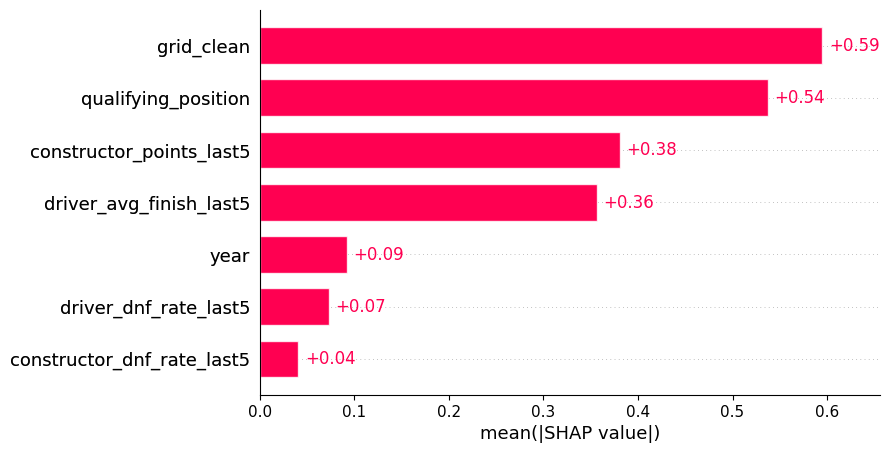

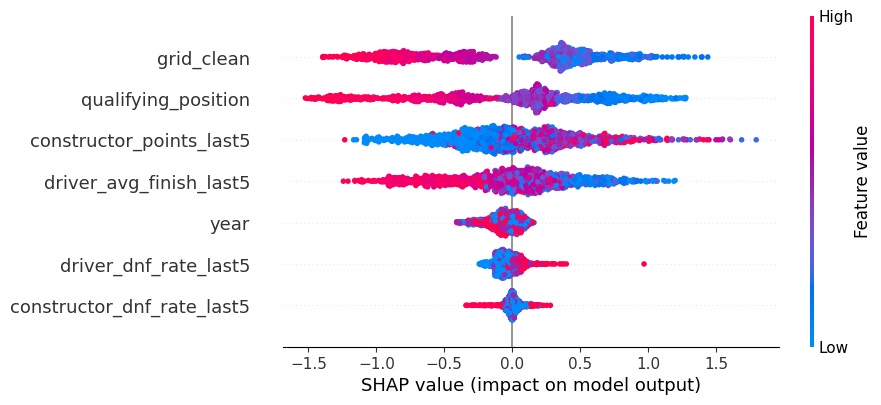

In [119]:
shap.plots.bar(shap_values)
shap.plots.beeswarm(shap_values)

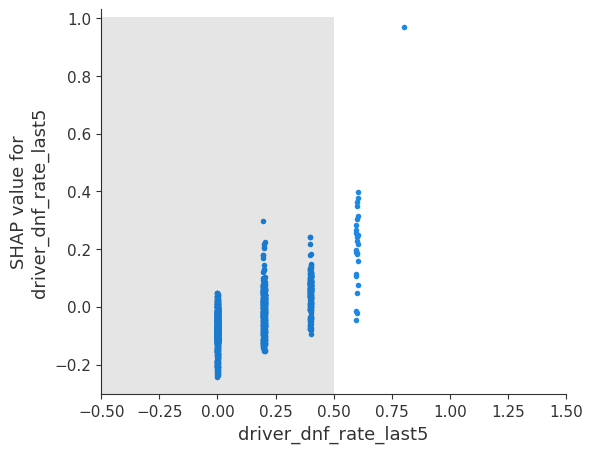

In [120]:
shap.plots.scatter(shap_values[:, "driver_dnf_rate_last5"])

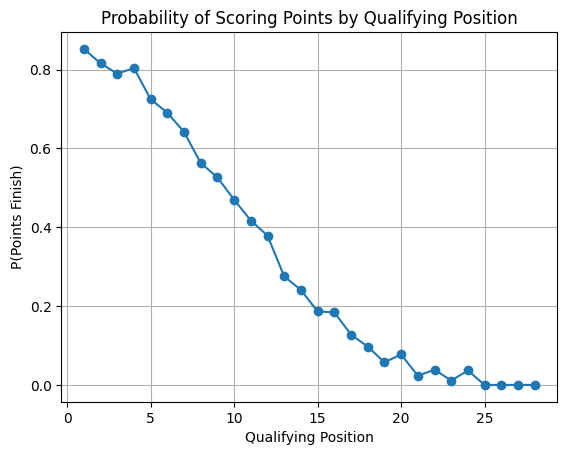

In [121]:
import matplotlib.pyplot as plt

qual_plot = (
    master.groupby("qualifying_position")["target_points"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(qual_plot["qualifying_position"], qual_plot["target_points"], marker="o")
plt.title("Probability of Scoring Points by Qualifying Position")
plt.xlabel("Qualifying Position")
plt.ylabel("P(Points Finish)")
plt.grid(True)
plt.show()

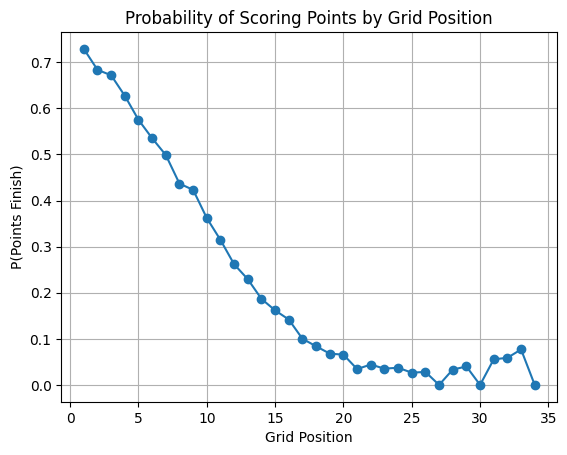

In [122]:
grid_plot = (
    master.groupby("grid_clean")["target_points"]
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(grid_plot["grid_clean"], grid_plot["target_points"], marker="o")
plt.title("Probability of Scoring Points by Grid Position")
plt.xlabel("Grid Position")
plt.ylabel("P(Points Finish)")
plt.grid(True)
plt.show()

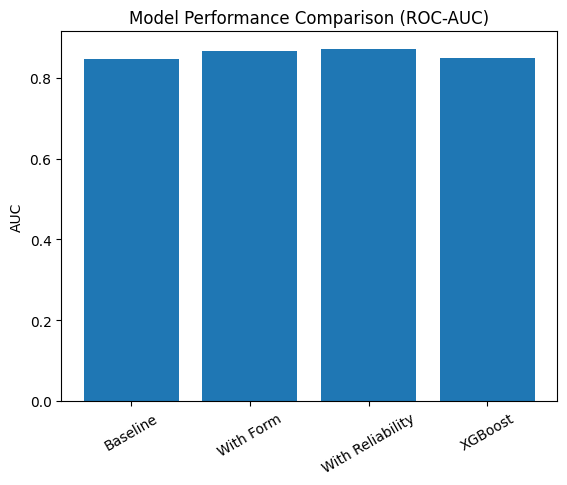

In [123]:
auc_df = pd.DataFrame({
    "Model": ["Baseline", "With Form", "With Reliability", "XGBoost"],
    "AUC": [0.846349, 0.865966, 0.870685, roc_auc_xgb]
})

plt.figure()
plt.bar(auc_df["Model"], auc_df["AUC"])
plt.title("Model Performance Comparison (ROC-AUC)")
plt.ylabel("AUC")
plt.xticks(rotation=30)
plt.show()

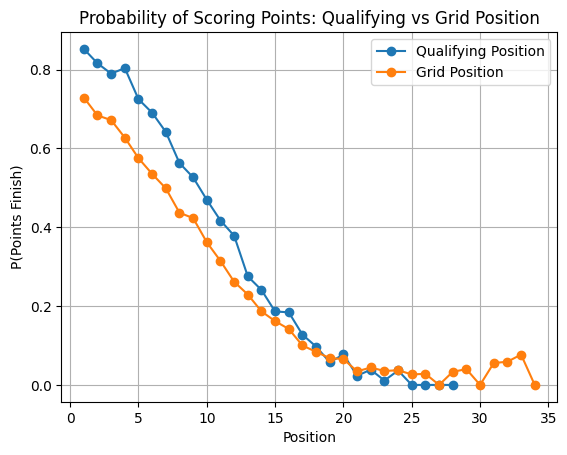

In [124]:
import matplotlib.pyplot as plt

# Aggregate both
qual_plot = (
    master.groupby("qualifying_position")["target_points"]
    .mean()
)

grid_plot = (
    master.groupby("grid_clean")["target_points"]
    .mean()
)

# Plot together
plt.figure()

plt.plot(
    qual_plot.index,
    qual_plot.values,
    marker="o",
    label="Qualifying Position"
)

plt.plot(
    grid_plot.index,
    grid_plot.values,
    marker="o",
    label="Grid Position"
)

plt.title("Probability of Scoring Points: Qualifying vs Grid Position")
plt.xlabel("Position")
plt.ylabel("P(Points Finish)")
plt.legend()
plt.grid(True)

plt.show()

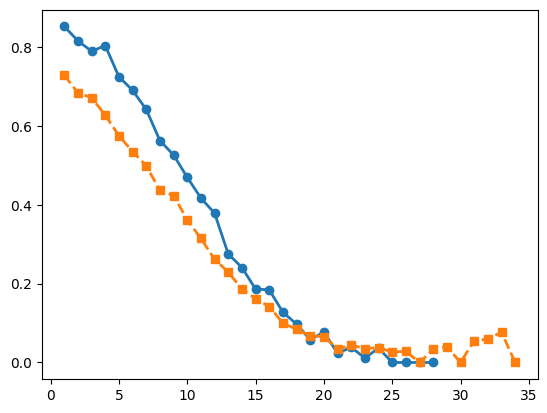

In [127]:
plt.plot(qual_plot.index, qual_plot.values, marker="o", linewidth=2, label="Qualifying")
plt.plot(grid_plot.index, grid_plot.values, marker="s", linewidth=2, linestyle="--", label="Grid")

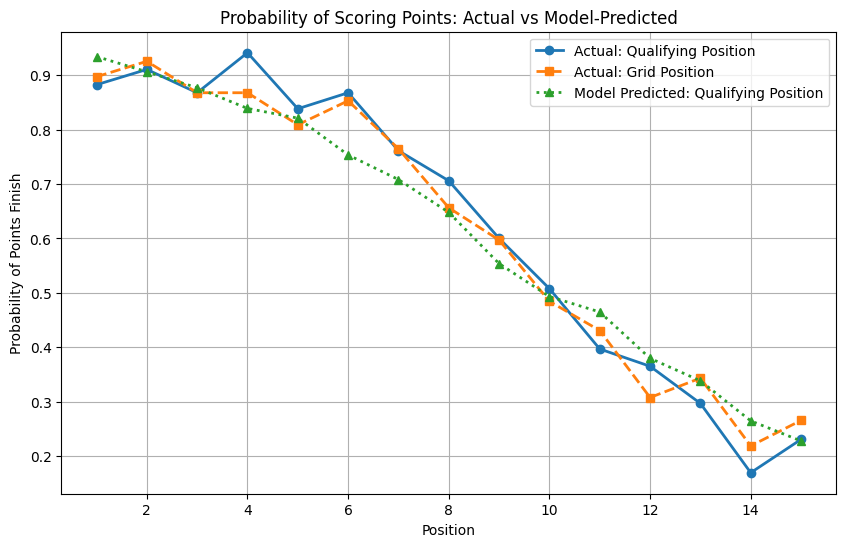

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# Recreate predictions on test set
feature_cols = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "constructor_points_last5",
    "driver_dnf_rate_last5",
    "constructor_dnf_rate_last5",
    "year"
]

X_test = test_v3[feature_cols].copy()
y_test = test_v3["target_points"].copy()

test_plot = test_v3.copy()
test_plot["pred_points_prob"] = model_lr_v3.predict_proba(X_test)[:, 1]

# Actual by qualifying position
qual_actual = (
    test_plot.groupby("qualifying_position")["target_points"]
    .mean()
    .reset_index()
    .sort_values("qualifying_position")
)

# Actual by grid position
grid_actual = (
    test_plot.groupby("grid_clean")["target_points"]
    .mean()
    .reset_index()
    .sort_values("grid_clean")
)

# Predicted by qualifying position
qual_pred = (
    test_plot.groupby("qualifying_position")["pred_points_prob"]
    .mean()
    .reset_index()
    .sort_values("qualifying_position")
)

# Optional: keep only top 15 positions for readability
qual_actual = qual_actual[qual_actual["qualifying_position"] <= 15]
grid_actual = grid_actual[grid_actual["grid_clean"] <= 15]
qual_pred = qual_pred[qual_pred["qualifying_position"] <= 15]

plt.figure(figsize=(10, 6))

plt.plot(
    qual_actual["qualifying_position"],
    qual_actual["target_points"],
    marker="o",
    linewidth=2,
    label="Actual: Qualifying Position"
)

plt.plot(
    grid_actual["grid_clean"],
    grid_actual["target_points"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Actual: Grid Position"
)

plt.plot(
    qual_pred["qualifying_position"],
    qual_pred["pred_points_prob"],
    marker="^",
    linestyle=":",
    linewidth=2,
    label="Model Predicted: Qualifying Position"
)

plt.title("Probability of Scoring Points: Actual vs Model-Predicted")
plt.xlabel("Position")
plt.ylabel("Probability of Points Finish")
plt.grid(True)
plt.legend()
plt.show()

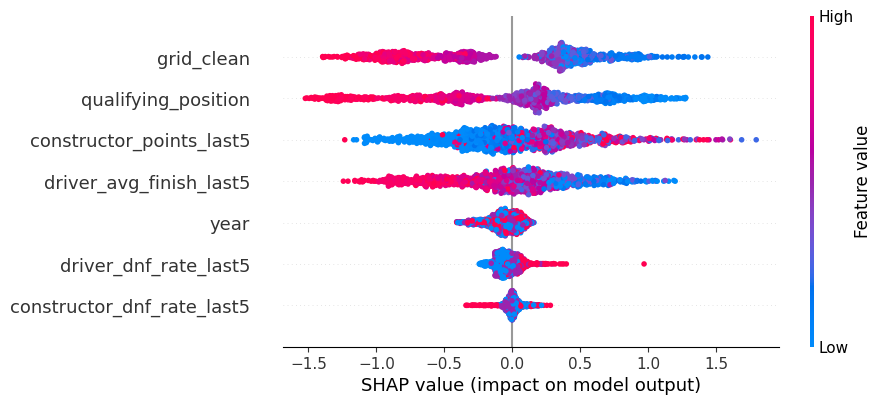

In [129]:
import shap

explainer = shap.Explainer(model_xgb)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

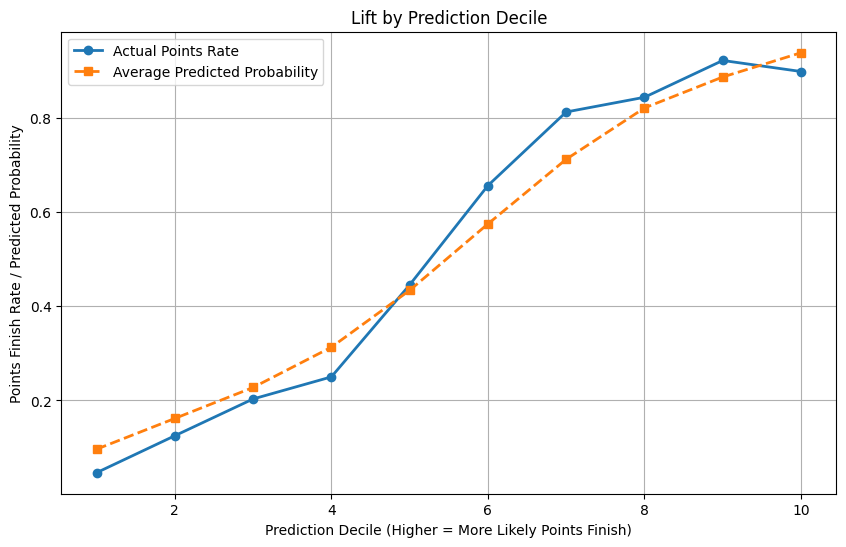

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

lift_df = test_v3.copy()
lift_df["pred_points_prob"] = model_lr_v3.predict_proba(X_test)[:, 1]

# Create deciles
lift_df["score_decile"] = pd.qcut(
    lift_df["pred_points_prob"],
    q=10,
    labels=False,
    duplicates="drop"
)

# Make decile 10 the highest-score bucket
lift_df["score_decile"] = lift_df["score_decile"] + 1

decile_perf = (
    lift_df.groupby("score_decile")
    .agg(
        actual_points_rate=("target_points", "mean"),
        avg_pred_prob=("pred_points_prob", "mean"),
        n=("target_points", "size")
    )
    .reset_index()
    .sort_values("score_decile")
)

plt.figure(figsize=(10, 6))
plt.plot(
    decile_perf["score_decile"],
    decile_perf["actual_points_rate"],
    marker="o",
    linewidth=2,
    label="Actual Points Rate"
)
plt.plot(
    decile_perf["score_decile"],
    decile_perf["avg_pred_prob"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Average Predicted Probability"
)

plt.title("Lift by Prediction Decile")
plt.xlabel("Prediction Decile (Higher = More Likely Points Finish)")
plt.ylabel("Points Finish Rate / Predicted Probability")
plt.grid(True)
plt.legend()
plt.show()

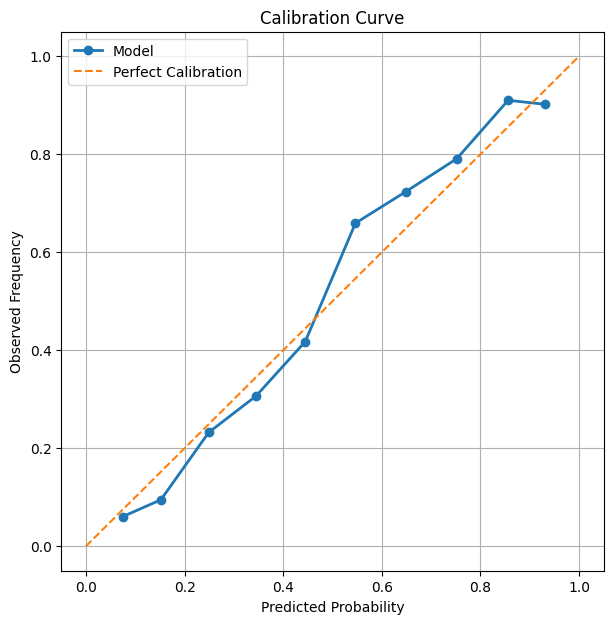

In [131]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    model_lr_v3.predict_proba(X_test)[:, 1],
    n_bins=10
)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.grid(True)
plt.legend()
plt.show()